### **Import Libraries**

In [1]:
!pip install bambi pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 8.0 MB/s eta 0:00:00


In [2]:
import os
import time
from collections import defaultdict
import random
import re
import pandas as pd
import numpy as np

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar, cochrans_q
from scipy.stats import wilcoxon, friedmanchisquare, chi2_contingency, spearmanr
import bambi as bmb
import pymc as pm
import arviz as az

from google.colab import drive
from google.colab.output import eval_js

random.seed(42)


In [3]:
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/st5230_project/output_A')


Mounted at /content/drive


### **Load evals**

In [4]:
KEYWORDS_HEDGE = [
    "perhaps", "maybe", "possibly", "likely",
    "it seems", "it appears", "i think",
    "may", "might", "could"
]

KEYWORDS_CONFIDENCE = [
    "clearly", "definitely", "certainly",
    "indeed", "in fact", "undoubtedly",
    "it is clear that"
]

def count_keywords(text, keywords):
    text = str(text).lower()
    total = 0
    for kw in keywords:
        total += len(re.findall(r"\b" + re.escape(kw) + r"\b", text))
    return total

def add_text_features(df):
    df = df.copy()
    df["question_id"] = df["id"].astype(str)
    df["re_answer"] = df["re_answer"].fillna("").astype(str)
    df["word_count"] = df["re_answer"].apply(lambda x: len(x.split()))
    df["log_length"] = np.log1p(df["word_count"])
    df["hedging_count"] = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_HEDGE))
    df["confidence_count"] = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_CONFIDENCE))
    return df

# Load .csv files
df_correct = pd.read_csv('3a_eval_correct.csv')
df_incorrect_ext = pd.read_csv('3a_eval_incorrect_ext.csv')
df_incorrect_int = pd.read_csv('3a_eval_incorrect_int.csv')

# Preprocess
df_correct = add_text_features(df_correct)
df_incorrect_ext = add_text_features(df_incorrect_ext)
df_incorrect_int = add_text_features(df_incorrect_int)

# Concat
df_all = pd.concat([df_correct, df_incorrect_ext, df_incorrect_int], ignore_index=True)
df_all['question_id'] = df_all['id'].astype(str)

print(df_all.shape)
df_all[['ans_type', 're_fluency', 'ground_truth_ind']].value_counts().sort_index()


(1120, 19)


ans_type       re_fluency  ground_truth_ind
correct        high        1                   140
               low         1                   140
incorrect_ext  attack      0                   140
               high        0                   140
               low         0                   140
incorrect_int  attack      0                   140
               high        0                   140
               low         0                   140
Name: count, dtype: int64

### **1. Metrics**

#### Bootstrapping

In [6]:
np.random.seed(42)
B = 2000

def bootstrap_ci(df, metric_fn, judge_col, truth_col="ground_truth_ind", B=2000):
    question_ids = df["question_id"].unique()
    n = len(question_ids)
    scores = []
    for _ in range(B):
        sampled_ids = np.random.choice(question_ids, size=n, replace=True)
        sample = df[df["question_id"].isin(sampled_ids)]
        try:
            scores.append(metric_fn(sample[truth_col], sample[judge_col]))
        except:
            continue
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)


#### Accuracy
- Qn: Out of all answers, how often did the judge get the label right?

In [7]:
def calc_acc(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

rows = []
for ans_type, subset in [("overall", df_all),
                          ("correct", df_all[df_all["ans_type"]=="correct"]),
                          ("incorrect_ext", df_all[df_all["ans_type"]=="incorrect_ext"]),
                          ("incorrect_int", df_all[df_all["ans_type"]=="incorrect_int"])]:

    acc_j1 = calc_acc(subset["ground_truth_ind"], subset["judge_1_ind"])
    acc_j2 = calc_acc(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_acc, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_acc, "judge_2_ind")

    rows.append({
        "ans_type": ans_type,
        "Judge 1 (GPT): accuracy": round(acc_j1, 3),
        "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): accuracy": round(acc_j2, 3),
        "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_1 = pd.DataFrame(rows).set_index("ans_type")
metric_1


,Judge 1 (GPT): accuracy,Judge 1 (GPT): 95% CI,Judge 2 (Claude): accuracy,Judge 2 (Claude): 95% CI
ans_type,,,,
overall,0.907,"[0.888, 0.927]",0.913,"[0.897, 0.931]"
correct,0.957,"[0.939, 0.979]",0.871,"[0.843, 0.902]"
incorrect_ext,0.964,"[0.945, 0.985]",0.979,"[0.966, 0.993]"
incorrect_int,0.817,"[0.777, 0.861]",0.876,"[0.843, 0.911]"


#### FAR
- Qn: Among answers that are actually wrong, how often did the judge wrongly say they were correct?

In [8]:
def calc_far(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = (y_true == 0)
    return np.mean(y_pred[mask] == 1)

rows = []
for ans_type, subset in [("overall", df_all),
                          ("incorrect_ext", df_all[df_all["ans_type"]=="incorrect_ext"]),
                          ("incorrect_int", df_all[df_all["ans_type"]=="incorrect_int"])]:

    far_j1 = calc_far(subset["ground_truth_ind"], subset["judge_1_ind"])
    far_j2 = calc_far(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_far, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_far, "judge_2_ind")

    rows.append({
        "ans_type": ans_type,
        "Judge 1 (GPT): FAR": round(far_j1, 3),
        "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): FAR": round(far_j2, 3),
        "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_2 = pd.DataFrame(rows).set_index("ans_type")
metric_2


,Judge 1 (GPT): FAR,Judge 1 (GPT): 95% CI,Judge 2 (Claude): FAR,Judge 2 (Claude): 95% CI
ans_type,,,,
overall,0.110,"[0.082, 0.134]",0.073,"[0.051, 0.093]"
incorrect_ext,0.036,"[0.014, 0.054]",0.021,"[0.007, 0.034]"
incorrect_int,0.183,"[0.139, 0.225]",0.124,"[0.087, 0.156]"


#### FRR
- Qn: Among answers that are actually correct, how often did the judge wrongly say they were incorrect?

In [9]:
def calc_frr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = (y_true == 1)
    return np.mean(y_pred[mask] == 0)

rows = []
for fluency, subset in [
    ("overall", df_correct),
    ("low", df_correct[df_correct["re_fluency"]=="low"]),
    ("high", df_correct[df_correct["re_fluency"]=="high"])
]:

    frr_j1 = calc_frr(subset["ground_truth_ind"], subset["judge_1_ind"])
    frr_j2 = calc_frr(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_frr, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_frr, "judge_2_ind")

    rows.append({
        "fluency": fluency,
        "Judge 1 (GPT): FRR": round(frr_j1, 3),
        "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): FRR": round(frr_j2, 3),
        "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_3 = pd.DataFrame(rows).set_index("fluency")
metric_3


,Judge 1 (GPT): FRR,Judge 1 (GPT): 95% CI,Judge 2 (Claude): FRR,Judge 2 (Claude): 95% CI
fluency,,,,
overall,0.043,"[0.022, 0.062]",0.129,"[0.101, 0.157]"
low,0.050,"[0.022, 0.077]",0.193,"[0.143, 0.241]"
high,0.036,"[0.011, 0.057]",0.064,"[0.033, 0.092]"


#### Cohen’s kappa
- Qn: How strongly does the judge agree with the ground truth, after adjusting for agreement that could happen just by chance?

In [10]:
def calc_kappa(y_true, y_pred):
    return cohen_kappa_score(np.asarray(y_true), np.asarray(y_pred))

rows = []

# Overall
kappa_j1 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_1_ind"])
kappa_j2 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_2_ind"])
lo_j1, hi_j1 = bootstrap_ci(df_all, calc_kappa, "judge_1_ind")
lo_j2, hi_j2 = bootstrap_ci(df_all, calc_kappa, "judge_2_ind")
rows.append({
    "breakdown": "overall", "ans_type": "all", "fluency": "all",
    "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
    "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
})

# Breakdown by answer type
for ans_type in ["incorrect_ext", "incorrect_int"]:
    subset = df_all[df_all["ans_type"].isin(["correct", ans_type])]
    kappa_j1 = calc_kappa(subset["ground_truth_ind"], subset["judge_1_ind"])
    kappa_j2 = calc_kappa(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_kappa, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_kappa, "judge_2_ind")
    rows.append({
        "breakdown": "by_ans_type", "ans_type": f"correct vs {ans_type}", "fluency": "all",
        "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

# Breakdown by answer type + fluency
for ans_type in ["incorrect_ext", "incorrect_int"]:
    for fluency in ["low", "high", "attack"]:
        inc_sub = df_all[(df_all["ans_type"] == ans_type) & (df_all["re_fluency"] == fluency)]
        cor_sub = df_correct if fluency == "attack" else df_correct[df_correct["re_fluency"] == fluency]
        subset = pd.concat([cor_sub, inc_sub], ignore_index=True)
        kappa_j1 = calc_kappa(subset["ground_truth_ind"], subset["judge_1_ind"])
        kappa_j2 = calc_kappa(subset["ground_truth_ind"], subset["judge_2_ind"])
        lo_j1, hi_j1 = bootstrap_ci(subset, calc_kappa, "judge_1_ind")
        lo_j2, hi_j2 = bootstrap_ci(subset, calc_kappa, "judge_2_ind")
        rows.append({
            "breakdown": "by_fluency", "ans_type": f"correct vs {ans_type}", "fluency": fluency,
            "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
            "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
        })

metric_4 = pd.DataFrame(rows).set_index(["breakdown", "ans_type", "fluency"])
metric_4


Judge 1 (GPT): κ  \
breakdown   ans_type                 fluency                     
overall     all                      all                 0.774   
by_ans_type correct vs incorrect_ext all                 0.920   
            correct vs incorrect_int all                 0.745   
by_fluency  correct vs incorrect_ext low                 0.921   
                                     high                0.943   
                                     attack              0.894   
            correct vs incorrect_int low                 0.779   
                                     high                0.821   
                                     attack              0.750   

                                             Judge 1 (GPT): 95% CI  \
breakdown   ans_type                 fluency                         
overall     all                      all            [0.732, 0.822]   
by_ans_type correct vs incorrect_ext all             [0.893, 0.95]   
            correct vs incorrect_int all            [0.697, 0.799]   
by_fluency  correct vs incorrect_ext low            [0.886, 0.956]   
                                     high           [0.917, 0.969]   
                                     attack         [0.857, 0.931]   
            correct vs incorrect_int low            [0.726, 0.835]   
                                     high           [0.771, 0.874]   
                                     attack         [0.697, 0.802]   

                                              Judge 2 (Claude): κ  \
breakdown   ans_type                 fluency                        
overall     all                      all                    0.776   
by_ans_type correct vs incorrect_ext all                    0.864   
            correct vs incorrect_int all                    0.741   
by_fluency  correct vs incorrect_ext low                    0.793   
                                     high                   0.921   
                                     attack                 0.792   
            correct vs incorrect_int low                    0.679   
                                     high                   0.843   
                                     attack                 0.703   

                                             Judge 2 (Claude): 95% CI  
breakdown   ans_type                 fluency                           
overall     all                      all               [0.736, 0.816]  
by_ans_type correct vs incorrect_ext all               [0.833, 0.893]  
            correct vs incorrect_int all                [0.694, 0.79]  
by_fluency  correct vs incorrect_ext low               [0.744, 0.844]  
                                     high               [0.89, 0.956]  
                                     attack            [0.753, 0.835]  
            correct vs incorrect_int low               [0.615, 0.741]  
                                     high              [0.795, 0.892]  
                                     attack            [0.651, 0.756]

### **2. Statistical Tests**

#### Check fluency
- Qn: Did the rewriting actually produce different hedging, confidence, and word counts across fluency conditions? (Manipulation check)

In [11]:
BONFERRONI_THRESHOLD = 0.05 / 3
METRICS = ["hedging_count", "confidence_count", "word_count"]
PAIRS = [("low", "high"), ("low", "attack"), ("high", "attack")]

df_pool_a = pd.concat([df_correct, df_incorrect_ext, df_incorrect_int], ignore_index=True)

# Aggregate by question_id + re_fluency to get one value per question per condition
df_pool_a_agg = df_pool_a.groupby(["question_id", "re_fluency"])[METRICS].mean().reset_index()

print(f"\n{'='*100}")
print(f"  Wilcoxon Signed-Rank — Pool A (overall)")
print(f"{'='*100}")

rows = []
for metric in METRICS:
    for fl_a, fl_b in PAIRS:
        a = df_pool_a_agg[df_pool_a_agg["re_fluency"] == fl_a].set_index("question_id")[metric]
        b = df_pool_a_agg[df_pool_a_agg["re_fluency"] == fl_b].set_index("question_id")[metric]
        paired = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
        diff = paired["a"] - paired["b"]

        if (diff == 0).all():
            rows.append({
                "Metric": metric,
                "Comparison": f"{fl_a} vs {fl_b}",
                "1st: Mean": "—",
                "2nd: Mean": "—",
                "W": "N/A",
                "p-value": "N/A",
                "Significant": "✗ (no difference)",
            })
            continue

        stat, p = wilcoxon(paired["a"], paired["b"])
        rows.append({
            "Metric": metric,
            "Comparison": f"{fl_a} vs {fl_b}",
            "1st: Mean": f"{paired['a'].mean():.3f}",
            "2nd: Mean": f"{paired['b'].mean():.3f}",
            "W": f"{stat:.4f}",
            "p-value": f"{p:.4f}",
            "Significant": "✓" if p < BONFERRONI_THRESHOLD else "✗ (no difference)",
        })

print(pd.DataFrame(rows).set_index(["Metric", "Comparison"]).to_string())



  Wilcoxon Signed-Rank — Pool A (overall)
                                1st: Mean 2nd: Mean          W p-value        Significant
Metric           Comparison                                                              
hedging_count    low vs high        1.802     0.005     0.0000  0.0000                  ✓
                 low vs attack      1.802     0.007     0.0000  0.0000                  ✓
                 high vs attack     0.005     0.007     1.0000  0.6547  ✗ (no difference)
confidence_count low vs high        0.000     1.281     0.0000  0.0000                  ✓
                 low vs attack      0.000     0.007     0.0000  0.1573  ✗ (no difference)
                 high vs attack     1.281     0.007     0.0000  0.0000                  ✓
word_count       low vs high       10.990    17.390     0.0000  0.0000                  ✓
                 low vs attack     10.990    17.550     1.0000  0.0000                  ✓
                 high vs attack    17.390    17.550  4271

#### Incorrect: vs Judge
- Qn: Do Judge 1 and Judge 2 make different errors on the same items?

In [12]:
eval_js('google.colab.output.setIframeHeight("300")')

# Error indicator for incorrect answers:
# judge_ind = 1 means judge predicted CORRECT on a hallucinated answer -> falsely accepted (error)
# judge_ind = 0 means judge predicted HALLUCINATED -> correctly rejected (no error)
df_incorrect = df_all[df_all["ground_truth_ind"] == 0].copy()
df_incorrect["judge_1_error"] = df_incorrect["judge_1_ind"]
df_incorrect["judge_2_error"] = df_incorrect["judge_2_ind"]

# Build contingency table (2x2)
table = pd.crosstab(df_incorrect["judge_1_error"], df_incorrect["judge_2_error"])
table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# Display contingency table
table_display = table.copy()
table_display.index   = ["J1 detected (0)", "J1 missed (1)"] # Predictions
table_display.columns = ["J2 detected (0)", "J2 missed (1)"]
table_display.index.name = None
table_display.columns.name = None

print(f"\n{'='*55}")
print(f"  McNemar's Test")
print(f"{'='*55}")
print(table_display.to_string())

# Optional descriptive error rates
j1_error_rate = df_incorrect["judge_1_error"].mean()
j2_error_rate = df_incorrect["judge_2_error"].mean()

print(f"\n  J1 error rate: {j1_error_rate:.3f}")
print(f"  J2 error rate: {j2_error_rate:.3f}")

# McNemar's test
result = mcnemar(table, exact=False, correction=True)

print(f"\n  McNemar χ² = {result.statistic:.3f}")
print(f"  p-value    = {result.pvalue:.3f}")

# Interpretation
if result.pvalue < 0.05:
    b = table.loc[0, 1]  # J1 caught, J2 missed
    c = table.loc[1, 0]  # J1 missed, J2 caught

    if b > c:
        print("  ✓ Significant (p< 0.05) — Judge 2 makes significantly more errors.")
    elif c > b:
        print("  ✓ Significant (p < 0.05) — Judge 1 makes significantly more errors.")
    else:
        print("  ✓ Significant (p < 0.05) — judges differ, but discordant counts are tied.")
else:
    print("  ✗ Not significant — no systematic difference in judge errors on the same wrong items.")



  McNemar's Test
                 J2 detected (0)  J2 missed (1)
J1 detected (0)              737             11
J1 missed (1)                 42             50

  J1 error rate: 0.110
  J2 error rate: 0.073

  McNemar χ² = 16.981
  p-value    = 0.000
  ✓ Significant (p < 0.05) — Judge 1 makes significantly more errors.


#### Incorrect: vs Type
- Qn: Do Judge 1 and Judge 2 make more errors on internal hallucinations than external hallucinations?


In [13]:
eval_js('google.colab.output.setIframeHeight("300")')

judge_names = {"judge_1_ind": "Judge 1 (GPT)", "judge_2_ind": "Judge 2 (Claude)"}

for judge, judge_name in judge_names.items():
    ext_errors = df_incorrect_ext.groupby("id")[judge].max().rename("ext")
    int_errors = df_incorrect_int.groupby("id")[judge].max().rename("int")
    paired = pd.concat([ext_errors, int_errors], axis=1).dropna()

    # Build contingency table (2x2)
    table = pd.crosstab(paired["ext"], paired["int"])
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    # Display contingency table
    table_display.index   = ["ext: detected (0)", "ext: missed (1)"]
    table_display.columns = ["int: detected (0)", "int: missed (1)"]
    table_display.index.name = None
    table_display.columns.name = None

    print(f"\n{'='*55}")
    print(f"  McNemar's — {judge_name}")
    print(f"{'='*55}")
    print(table_display.to_string())

    # Error rates
    print(f"\n  ext error rate: {paired['ext'].mean():.3f}")
    print(f"  int error rate: {paired['int'].mean():.3f}")

    # McNemar's test
    result = mcnemar(table, exact=False, correction=True)
    print(f"\n  McNemar χ²  = {result.statistic:.3f}")
    print(f"  p-value     = {result.pvalue:.3f}")

    # Interpretation
    b = table.loc[0, 1]  # detected ext, falsely accepted int
    c = table.loc[1, 0]  # falsely accepted ext, detected int
    if result.pvalue < 0.05:
        harder = "incorrect_int" if b > c else "incorrect_ext"
        print(f"  ✓ Significant (p < 0.05) — {judge_name} is systematically more fooled by '{harder}'")
    else:
        print(f"  ✗ Not significant — no systematic difference between ext and int for {judge_name}")



  McNemar's — Judge 1 (GPT)
                   int: detected (0)  int: missed (1)
ext: detected (0)                737               11
ext: missed (1)                   42               50

  ext error rate: 0.057
  int error rate: 0.279

  McNemar χ²  = 24.324
  p-value     = 0.000
  ✓ Significant (p < 0.05) — Judge 1 (GPT) is systematically more fooled by 'incorrect_int'

  McNemar's — Judge 2 (Claude)
                   int: detected (0)  int: missed (1)
ext: detected (0)                737               11
ext: missed (1)                   42               50

  ext error rate: 0.043
  int error rate: 0.207

  McNemar χ²  = 17.926
  p-value     = 0.000
  ✓ Significant (p < 0.05) — Judge 2 (Claude) is systematically more fooled by 'incorrect_int'


#### Incorrect: vs Fluency
- Qn: Do judges make different numbers of errors across low, high, and attack hallucination styles?
- Qn: Based on previous qn, for Judge 1, which pairs of styles differ in error rate?


In [14]:
eval_js('google.colab.output.setIframeHeight("300")')

judge_names = {"judge_1_ind": "Judge 1 (GPT)", "judge_2_ind": "Judge 2 (Claude)"}

for ans_type, df_type in [("incorrect_ext", df_incorrect_ext), ("incorrect_int", df_incorrect_int)]:
    print(f"\n{'='*100}")
    print(f"  Cochran's Q — {ans_type}")
    print(f"{'='*100}")

    rows = []
    results = {}

    for judge, judge_name in judge_names.items():
        low    = df_type[df_type["re_fluency"] == "low"].set_index("id")[judge].rename("low")
        high   = df_type[df_type["re_fluency"] == "high"].set_index("id")[judge].rename("high")
        attack = df_type[df_type["re_fluency"] == "attack"].set_index("id")[judge].rename("attack")
        paired = pd.concat([low, high, attack], axis=1).dropna()

        result = cochrans_q(paired)
        results[judge_name] = result

        rows.append({
            "Judge": judge_name,
            "FNR: low |": f"{paired['low'].mean():.3f}",
            "FNR: high |": f"{paired['high'].mean():.3f}",
            "FNR: attack |": f"{paired['attack'].mean():.3f}",
            "Cochran's Q |": f"{result.statistic:.3f}",
            "p-value |": f"{result.pvalue:.3f}",
            "Significant": "✓" if result.pvalue < 0.05 else "✗",
        })

    # Display as table
    summary = pd.DataFrame(rows).set_index("Judge")
    print(summary.to_string())

    # Conclusions
    print()
    for judge_name, result in results.items():
        if result.pvalue < 0.05:
            print(f"  ✓ {judge_name}: error rates differ significantly across fluency levels → run pairwise McNemar's")
        else:
            print(f"  ✗ {judge_name}: no significant difference across fluency levels")



  Cochran's Q — incorrect_ext
                 FNR: low | FNR: high | FNR: attack | Cochran's Q | p-value | Significant
Judge                                                                                    
Judge 1 (GPT)         0.029       0.021         0.057         8.400     0.015           ✓
Judge 2 (Claude)      0.014       0.014         0.036         3.600     0.165           ✗

  ✓ Judge 1 (GPT): error rates differ significantly across fluency levels → run pairwise McNemar's
  ✗ Judge 2 (Claude): no significant difference across fluency levels

  Cochran's Q — incorrect_int
                 FNR: low | FNR: high | FNR: attack | Cochran's Q | p-value | Significant
Judge                                                                                    
Judge 1 (GPT)         0.171       0.143         0.236        11.083     0.004           ✓
Judge 2 (Claude)      0.129       0.093         0.150         4.900     0.086           ✗

  ✓ Judge 1 (GPT): error rates differ significa

In [15]:
eval_js('google.colab.output.setIframeHeight("300")')
BONFERRONI_THRESHOLD = 0.05 / 3
fluency_pairs = [("low", "high"), ("low", "attack"), ("high", "attack")]

for ans_type, df_type in [("incorrect_ext", df_incorrect_ext), ("incorrect_int", df_incorrect_int)]:
    print(f"\n{'='*75}")
    print(f"  McNemar's — Judge 1 (GPT) X {ans_type}")
    print(f"{'='*75}")

    rows = []
    for fl_a, fl_b in fluency_pairs:
        a = df_type[df_type["re_fluency"] == fl_a].set_index("id")["judge_1_ind"].rename(fl_a)
        b = df_type[df_type["re_fluency"] == fl_b].set_index("id")["judge_1_ind"].rename(fl_b)
        paired = pd.concat([a, b], axis=1).dropna()

        table  = pd.crosstab(paired[fl_a], paired[fl_b])
        table  = table.reindex(index=[0,1], columns=[0,1], fill_value=0)
        result = mcnemar(table, exact=False, correction=True)

        b_cell = table.loc[0, 1]  # detected fl_a, falsely accepted fl_b
        c_cell = table.loc[1, 0]  # falsely accepted fl_a, detected fl_b

        rows.append({
            "Comparison": f"{fl_a} vs {fl_b}",
            "1st: FNR |": f"{paired[fl_a].mean():.3f}",
            "2nd: FNR |": f"{paired[fl_b].mean():.3f}",
            "McNemar χ² |": f"{result.statistic:.3f}",
            "p-value |": f"{result.pvalue:.3f}",
            "Significant": "✓" if result.pvalue < BONFERRONI_THRESHOLD else "✗",
        })

    summary = pd.DataFrame(rows).set_index("Comparison")
    print(summary.to_string())

    # Conclusions
    print()
    for row in rows:
        if row["Significant"] == "✓":
            print(f"  ✓ {row['Comparison']}: significant after Bonferroni correction")
        else:
            print(f"  ✗ {row['Comparison']}: not significant after Bonferroni correction")



  McNemar's — Judge 1 (GPT) X incorrect_ext
               1st: FNR | 2nd: FNR | McNemar χ² | p-value | Significant
Comparison                                                             
low vs high         0.029      0.021        0.000     1.000           ✗
low vs attack       0.029      0.057        2.250     0.134           ✗
high vs attack      0.021      0.057        3.200     0.074           ✗

  ✗ low vs high: not significant after Bonferroni correction
  ✗ low vs attack: not significant after Bonferroni correction
  ✗ high vs attack: not significant after Bonferroni correction

  McNemar's — Judge 1 (GPT) X incorrect_int
               1st: FNR | 2nd: FNR | McNemar χ² | p-value | Significant
Comparison                                                             
low vs high         0.171      0.143        1.125     0.289           ✗
low vs attack       0.171      0.236        3.368     0.066           ✗
high vs attack      0.143      0.236        6.857     0.009           ✓



#### Correct vs Judge
- Qn: Do Judge 1 and Judge 2 make different false rejections on correct answers?

In [16]:
eval_js('google.colab.output.setIframeHeight("300")')

# Error indicator for correct answers:
# 1 = judge predicted HALLUCINATED (ind=0) on a correct answer -> falsely rejected
# 0 = judge predicted CORRECT (ind=1) -> correctly accepted
df_correct["judge_1_error"] = (df_correct["judge_1_ind"] == 0).astype(int)
df_correct["judge_2_error"] = (df_correct["judge_2_ind"] == 0).astype(int)

# Build contingency table (2x2)
table = pd.crosstab(df_correct["judge_1_error"], df_correct["judge_2_error"])
table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# Display contingency table
table_display = table.copy()
table_display.index   = ["J1 accepted (0)", "J1 rejected (1)"]
table_display.columns = ["J2 accepted (0)", "J2 rejected (1)"]
table_display.index.name   = None
table_display.columns.name = None

print(f"\n{'='*55}")
print(f"  McNemar's Test — correct answers")
print(f"{'='*55}")
print(table_display.to_string())

# Optional descriptive error rates
j1_error_rate = df_correct["judge_1_error"].mean()
j2_error_rate = df_correct["judge_2_error"].mean()
print(f"\n  J1 error rate: {j1_error_rate:.3f}")
print(f"  J2 error rate: {j2_error_rate:.3f}")

# McNemar's test
result = mcnemar(table, exact=False, correction=True)
print(f"\n  McNemar χ² = {result.statistic:.3f}")
print(f"  p-value    = {result.pvalue:.3f}")

# Interpretation
b = table.loc[0, 1]  # J1 accepted, J2 rejected
c = table.loc[1, 0]  # J1 rejected, J2 accepted
if result.pvalue < 0.05:
    if b > c:
        print("✓ Significant (p<0.05) — Judge 2 (Claude) falsely rejects significantly more correct answers")
    elif c > b:
        print("✓ Significant (p<0.05) — Judge 1 (GPT) falsely rejects significantly more correct answers")
else:
    print("✗ Not significant — no systematic difference in false rejection between judges")



  McNemar's Test — correct answers
                 J2 accepted (0)  J2 rejected (1)
J1 accepted (0)              239               29
J1 rejected (1)                5                7

  J1 error rate: 0.043
  J2 error rate: 0.129

  McNemar χ² = 15.559
  p-value    = 0.000
✓ Significant (p<0.05) — Judge 2 (Claude) falsely rejects significantly more correct answers


#### Correct: vs Fluency
- Qn: For correct answers, is the judge more likely to falsely reject low or high style?

In [17]:
eval_js('google.colab.output.setIframeHeight("300")')

judge_names = {"judge_1_ind": "Judge 1 (GPT)", "judge_2_ind": "Judge 2 (Claude)"}

for judge, judge_name in judge_names.items():
    low  = df_correct[df_correct["re_fluency"] == "low"].set_index("id")[judge].rename("low")
    high = df_correct[df_correct["re_fluency"] == "high"].set_index("id")[judge].rename("high")
    paired = pd.concat([low, high], axis=1).dropna()

    # Build contingency table (2x2)
    paired["low_error"]  = (paired["low"] == 0).astype(int)
    paired["high_error"] = (paired["high"] == 0).astype(int)
    table = pd.crosstab(paired["low_error"], paired["high_error"])
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    # Display contingency table
    table_display = table.rename(
        index={0: "low: accepted (0)", 1: "low: rejected (1)"},
        columns={0: "high: accepted (0)", 1: "high: rejected (1)"}
    )
    table_display.index.name = None
    table_display.columns.name = None
    print(f"\n{'='*75}")
    print(f"  McNemar's — {judge_name} X correct")
    print(f"{'='*75}")
    print(table_display.to_string())

    # Error rates
    print(f"\n  low FRR:  {paired['low_error'].mean():.3f}")
    print(f"  high FRR: {paired['high_error'].mean():.3f}")

    result = mcnemar(table, exact=False, correction=True)
    print(f"\n  McNemar χ² = {result.statistic:.3f}")
    print(f"  p-value    = {result.pvalue:.3f}")

    b = table.loc[0, 1]
    c = table.loc[1, 0]
    if result.pvalue < 0.05:
        more_rejected = "high" if b > c else "low"
        print(f"  ✓ Significant (p < 0.05) — {judge_name} falsely rejects '{more_rejected}' style more")
    else:
        print(f"  ✗ Not significant — no systematic difference in false rejection between low and high")



  McNemar's — Judge 1 (GPT) X correct
                   high: accepted (0)  high: rejected (1)
low: accepted (0)                 130                   3
low: rejected (1)                   5                   2

  low FRR:  0.050
  high FRR: 0.036

  McNemar χ² = 0.125
  p-value    = 0.724
  ✗ Not significant — no systematic difference in false rejection between low and high

  McNemar's — Judge 2 (Claude) X correct
                   high: accepted (0)  high: rejected (1)
low: accepted (0)                 106                   7
low: rejected (1)                  25                   2

  low FRR:  0.193
  high FRR: 0.064

  McNemar χ² = 9.031
  p-value    = 0.003
  ✓ Significant (p < 0.05) — Judge 2 (Claude) falsely rejects 'low' style more


### **3. Statistical Models**

#### Preprocess data

In [5]:
### INCORRECT answers: From wide -> long format for models
def build_incorrect_long(df_ext, df_int):
    df_inc = pd.concat([df_ext, df_int], ignore_index=True).copy()

    # Judge 1 rows
    j1 = df_inc[[
        "question_id", "inc_type", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_1_ind", "judge_1_score"
    ]].copy()
    j1["judge"] = "Judge_1"
    j1["error"] = j1["judge_1_ind"]
    j1["score"] = j1["judge_1_score"]
    j1 = j1.drop(columns=["judge_1_ind", "judge_1_score"])

    # Judge 2 rows
    j2 = df_inc[[
        "question_id", "inc_type", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_2_ind", "judge_2_score"
    ]].copy()
    j2["judge"] = "Judge_2"
    j2["error"] = j2["judge_2_ind"]
    j2["score"] = j2["judge_2_score"]
    j2 = j2.drop(columns=["judge_2_ind", "judge_2_score"])

    # Stack into long format: 2 rows per answer (one per judge)
    out = pd.concat([j1, j2], ignore_index=True)

    # Set categorical dtypes with explicit reference levels
    out["judge"] = pd.Categorical(out["judge"], categories=["Judge_1", "Judge_2"])
    out["inc_type"] = pd.Categorical(out["inc_type"], categories=["external", "internal"])
    out["re_fluency"] = pd.Categorical(out["re_fluency"], categories=["low", "high", "attack"])
    return out

df_incorrect_ext["inc_type"] = "external"
df_incorrect_int["inc_type"] = "internal"
df_incorrect_long = build_incorrect_long(df_incorrect_ext, df_incorrect_int)
df_incorrect_long[["judge", "inc_type", "re_fluency"]].value_counts()


judge    inc_type  re_fluency
Judge_1  external  low           140
                   high          140
                   attack        140
         internal  low           140
                   high          140
                   attack        140
Judge_2  external  low           140
                   high          140
                   attack        140
         internal  low           140
                   high          140
                   attack        140
Name: count, dtype: int64

In [9]:
### CORRECT answers: From wide -> long format for models
def build_correct_long(df_cor):
    # Judge 1 rows
    j1 = df_cor[[
        "question_id", "inc_type", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_1_ind", "judge_1_score"
    ]].copy()
    j1["judge"] = "Judge_1"
    j1["error"] = 1 - j1["judge_1_ind"]           # correct: 1 = judge error
    j1["score"] = j1["judge_1_score"]
    j1 = j1.drop(columns=["judge_1_ind", "judge_1_score"])

    # Judge 2 rows
    j2 = df_cor[[
        "question_id", "inc_type", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_2_ind", "judge_2_score"
    ]].copy()
    j2["judge"] = "Judge_2"
    j2["error"] = 1 - j2["judge_2_ind"]
    j2["score"] = j2["judge_2_score"]
    j2 = j2.drop(columns=["judge_2_ind", "judge_2_score"])

    # Stack into long format: 2 rows per answer (one per judge)
    out = pd.concat([j1, j2], ignore_index=True)

    # Set categorical dtypes with explicit reference levels
    out["judge"] = pd.Categorical(out["judge"], categories=["Judge_1", "Judge_2"])
    out["re_fluency"] = pd.Categorical(
        out["re_fluency"], categories=["low", "high"]
    )
    return out

df_correct["inc_type"] = "correct"
df_correct_long = build_correct_long(df_correct)
df_correct_long[["judge", "inc_type", "re_fluency"]].value_counts()


judge    inc_type  re_fluency
Judge_1  correct   low           140
                   high          140
Judge_2  correct   low           140
                   high          140
Name: count, dtype: int64

#### Model A: Incorrect GLMM (general)
- Qn: For incorrect answers, what predicts the chance that the judge wrongly accepts the hallucination?

In [7]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_A = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + C(inc_type, Treatment('external')) * C(re_fluency, Treatment('low')) + log_length + (1|question_id)",
    data=df_incorrect_long,
    family="bernoulli"
)

idata_A = model_A.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_A = az.summary(idata_A, round_to=4)
summary_A = summary_A[display_cols].reset_index().rename(columns={"index": "term"})
summary_A["credible_effect"] = np.where(
    (summary_A["hdi_3%"] > 0) | (summary_A["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_A["term"] = (
    summary_A["term"]
    .str.replace(r"C\((\w+),\s*Treatment\('[^']+'\)\)", r"\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_A["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_A = summary_A[fixed_mask].copy()
odd_ratio_A["OR"] = np.exp(odd_ratio_A["mean"])
odd_ratio_A["OR_low"] = np.exp(odd_ratio_A["hdi_3%"])
odd_ratio_A["OR_high"] = np.exp(odd_ratio_A["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL A — Incorrect-only GLMM")
print("="*120)
print(summary_A.to_string(index=False))

print("\n" + "="*120)
print("  MODEL A — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_A[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL A — Incorrect-only GLMM
                                   term    mean     sd   hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[56de1563cffd8e1900b4b5c3] -1.6975 2.2574  -5.9787   2.1928  9581.1007 1.0003              No
1|question_id[56de1645cffd8e1900b4b5d2] -1.6848 2.2423  -5.9450   2.2200  9144.3020 1.0000              No
1|question_id[56de3d594396321400ee26ca]  1.1303 1.3115  -1.2939   3.5566  6698.5390 1.0007              No
1|question_id[56de4a89cffd8e1900b4b7bd]  4.1676 0.8450   2.5428   5.7300  5821.9252 0.9999             Yes
1|question_id[56e181d9e3433e1400422fa2] -1.7263 2.2571  -6.1153   2.0413  8662.5799 1.0011              No
1|question_id[56e1b00ce3433e140042309e] -1.6999 2.2218  -5.7466   2.2164 10910.2464 1.0003              No
1|question_id[56e1c4fce3433e1400423151] -1.7269 2.2727  -5.7551   2.3745  9119.9447 1.0003              No
1|question_id[56e20a3ae3433e140042324a] -1.7190 2.2679  -5.8404   2.3364  7968.8757 1.0001              No
1|qu

#### Model B: Incorrect GLMM (linguistic)
- Qn: For incorrect answers, are the judge errors better explained by measurable text features than by the coarse style label?

In [55]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_B = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + C(inc_type, Treatment('external')) + confidence_count + hedging_count + log_length + (1|question_id)",
    data=df_incorrect_long,
    family="bernoulli"
)

idata_B = model_B.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_B = az.summary(idata_B, round_to=4)
summary_B = summary_B[display_cols].reset_index().rename(columns={"index": "term"})
summary_B["credible_effect"] = np.where(
    (summary_B["hdi_3%"] > 0) | (summary_B["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_B["term"] = (
    summary_B["term"]
    .str.replace(r"C\((\w+),\s*Treatment\('[^']+'\)\)", r"\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_B["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_B = summary_B[fixed_mask].copy()
odd_ratio_B["OR"] = np.exp(odd_ratio_B["mean"])
odd_ratio_B["OR_low"] = np.exp(odd_ratio_B["hdi_3%"])
odd_ratio_B["OR_high"] = np.exp(odd_ratio_B["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL B — Linguistic-feature GLMM")
print("="*120)
print(summary_B.to_string(index=False))

print("\n" + "="*120)
print("  MODEL B — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_B[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL B — Linguistic-feature GLMM
                                   term    mean     sd   hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[56de1563cffd8e1900b4b5c3] -1.6244 2.2857  -5.9494   2.4009 11404.7617 0.9999              No
1|question_id[56de1645cffd8e1900b4b5d2] -1.6853 2.2921  -6.0219   2.3146  9173.2275 1.0013              No
1|question_id[56de3d594396321400ee26ca]  1.2301 1.3009  -1.0705   3.7204  7583.7048 1.0004              No
1|question_id[56de4a89cffd8e1900b4b7bd]  4.2272 0.8343   2.7302   5.8470  5375.1292 1.0001             Yes
1|question_id[56e181d9e3433e1400422fa2] -1.7655 2.2524  -5.9157   2.1294 10446.6302 1.0001              No
1|question_id[56e1b00ce3433e140042309e] -1.7678 2.2842  -6.1470   2.1251  9744.6591 1.0006              No
1|question_id[56e1c4fce3433e1400423151] -1.8342 2.2683  -6.1212   1.9783 10041.1812 1.0008              No
1|question_id[56e20a3ae3433e140042324a] -1.7491 2.3202  -6.2823   2.0557  9669.3274 1.0008              No


#### Model C: Correct GLMM (general)
- Qn:  For correct answers only, what predicts false rejection?

In [10]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_C = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + C(re_fluency, Treatment('low')) + log_length + (1|question_id)",
    data=df_correct_long,
    family="bernoulli"
)

idata_C = model_C.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_C = az.summary(idata_C, round_to=4)
summary_C = summary_C[display_cols].reset_index().rename(columns={"index": "term"})
summary_C["credible_effect"] = np.where(
    (summary_C["hdi_3%"] > 0) | (summary_C["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_C["term"] = (
    summary_C["term"]
    .str.replace(r"C\((\w+),\s*Treatment\('[^']+'\)\)", r"\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_C["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_C = summary_C[fixed_mask].copy()
odd_ratio_C["OR"] = np.exp(odd_ratio_C["mean"])
odd_ratio_C["OR_low"] = np.exp(odd_ratio_C["hdi_3%"])
odd_ratio_C["OR_high"] = np.exp(odd_ratio_C["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL C — Correct-only GLMM")
print("="*120)
print(summary_C.to_string(index=False))

print("\n" + "="*120)
print("  MODEL C — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_C[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL C — Correct-only GLMM
                                   term    mean     sd  hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[56de1563cffd8e1900b4b5c3] -0.5272 1.3343 -3.0482   1.9362 16199.2229 1.0010              No
1|question_id[56de1645cffd8e1900b4b5d2] -0.5572 1.3444 -3.2888   1.6960 13723.9973 1.0000              No
1|question_id[56de3d594396321400ee26ca]  0.9168 1.1652 -1.2651   3.1158 10701.2856 1.0006              No
1|question_id[56de4a89cffd8e1900b4b7bd] -0.5263 1.3117 -2.8567   1.9998 14785.1888 1.0017              No
1|question_id[56e181d9e3433e1400422fa2]  1.0381 1.1882 -1.2629   3.1810 10651.9441 1.0000              No
1|question_id[56e1b00ce3433e140042309e] -0.5186 1.3428 -2.9400   2.0743 14379.1669 1.0017              No
1|question_id[56e1c4fce3433e1400423151] -0.4761 1.3903 -3.1855   2.0471 16730.0459 1.0007              No
1|question_id[56e20a3ae3433e140042324a] -0.5289 1.3549 -3.2663   1.7585 14495.1247 1.0004              No
1|question_id[5

#### Model D: Correct GLMM (linguistic)
- Qn:  For correct answers, do confidence wording, hedging, and answer length affect how often judges wrongly reject a correct answer?

In [11]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_D = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + confidence_count + hedging_count + log_length + (1|question_id)",
    data=df_correct_long,
    family="bernoulli"
)

idata_D = model_D.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_D = az.summary(idata_D, round_to=4)
summary_D = summary_D[display_cols].reset_index().rename(columns={"index": "term"})
summary_D["credible_effect"] = np.where(
    (summary_D["hdi_3%"] > 0) | (summary_D["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_D["term"] = (
    summary_D["term"]
    .str.replace(r"C\\((\\w+),\\s*Treatment\\('[^']+'\\)\\)", r"\\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_D["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_D = summary_D[fixed_mask].copy()
odd_ratio_D["OR"] = np.exp(odd_ratio_D["mean"])
odd_ratio_D["OR_low"] = np.exp(odd_ratio_D["hdi_3%"])
odd_ratio_D["OR_high"] = np.exp(odd_ratio_D["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL D — Correct-only GLMM")
print("="*120)
print(summary_D.to_string(index=False))

print("\n" + "="*120)
print("  MODEL D — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_D[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL D — Correct-only GLMM
                                   term    mean     sd  hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[56de1563cffd8e1900b4b5c3] -0.5468 1.2846 -3.0240   1.7815 14885.8908 1.0000              No
1|question_id[56de1645cffd8e1900b4b5d2] -0.3630 1.3446 -2.8380   2.2087 15875.0708 1.0004              No
1|question_id[56de3d594396321400ee26ca]  0.7943 1.1039 -1.2268   2.9098 11624.3938 1.0014              No
1|question_id[56de4a89cffd8e1900b4b7bd] -0.5551 1.2537 -2.8509   1.8011 16794.7621 1.0003              No
1|question_id[56e181d9e3433e1400422fa2]  0.8755 1.1309 -1.2044   3.0175 10123.8331 0.9998              No
1|question_id[56e1b00ce3433e140042309e] -0.5367 1.2754 -2.8668   1.9115 17491.4285 1.0033              No
1|question_id[56e1c4fce3433e1400423151] -0.3397 1.3321 -2.7166   2.2935 18133.2860 1.0001              No
1|question_id[56e20a3ae3433e140042324a] -0.5250 1.2970 -3.0107   1.8494 15725.6531 1.0003              No
1|question_id[5

#### 2PL IRT: Incorrect

In [12]:
def build_irt_block(df, hall_type, judge_num):
    judge_ind = f"judge_{judge_num}_ind"
    judge_lab = f"j{judge_num}"

    # For incorrect answers only:
    # judge_ind = 0 means judge correctly caught the hallucination
    # judge_ind = 1 means judge missed it
    temp = df[["question_id", "re_fluency", judge_ind]].copy()

    # Convert to IRT response: 1 = correct detection, 0 = miss
    temp["response"] = (temp[judge_ind] == 0).astype(int)

    temp["item_name"] = hall_type + "_" + temp["re_fluency"].astype(str) + "_" + judge_lab
    wide = temp.pivot(index="question_id", columns="item_name", values="response")
    return wide

# Build response matrix
irt_ext_j1 = build_irt_block(df_incorrect_ext, "ext", 1)
irt_ext_j2 = build_irt_block(df_incorrect_ext, "ext", 2)
irt_int_j1 = build_irt_block(df_incorrect_int, "int", 1)
irt_int_j2 = build_irt_block(df_incorrect_int, "int", 2)
irt_matrix = pd.concat([irt_ext_j1, irt_ext_j2, irt_int_j1, irt_int_j2], axis=1)
irt_matrix = irt_matrix.reindex(sorted(irt_matrix.columns), axis=1)

print(irt_matrix.shape)


(140, 12)


In [13]:
def build_irt_block(df, hall_type, judge_num):
    judge_ind = f"judge_{judge_num}_ind"
    judge_lab = f"j{judge_num}"

    # For incorrect answers only:
    # judge_ind = 0 means judge correctly caught the hallucination
    # judge_ind = 1 means judge missed it
    temp = df[["question_id", "re_fluency", judge_ind]].copy()

    # Convert to IRT response: 1 = correct detection, 0 = miss
    temp["response"] = (temp[judge_ind] == 0).astype(int)

    temp["item_name"] = hall_type + "_" + temp["re_fluency"].astype(str) + "_" + judge_lab
    wide = temp.pivot(index="question_id", columns="item_name", values="response")
    return wide

# Build response matrix
irt_ext_j1 = build_irt_block(df_incorrect_ext, "ext", 1)
irt_ext_j2 = build_irt_block(df_incorrect_ext, "ext", 2)
irt_int_j1 = build_irt_block(df_incorrect_int, "int", 1)
irt_int_j2 = build_irt_block(df_incorrect_int, "int", 2)
irt_matrix = pd.concat([irt_ext_j1, irt_ext_j2, irt_int_j1, irt_int_j2], axis=1)
irt_matrix = irt_matrix.reindex(sorted(irt_matrix.columns), axis=1)

# Convert to numpy array
Y = irt_matrix.to_numpy().astype(int)
n_questions, n_items = Y.shape
question_ids = irt_matrix.index.tolist()
item_names = irt_matrix.columns.tolist()

# Fit model
with pm.Model() as irt_2pl:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=n_questions)  # Question ability: higher = easier for judges overall
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=n_items)           # Item discrimination: must be positive
    b = pm.Normal("b", mu=0.0, sigma=1.0, shape=n_items)              # Item difficulty
    logit_p = a * (theta[:, None] - b[None, :])                       # 2PL model

    pm.Bernoulli("y", logit_p=logit_p, observed=Y)
    idata_irt = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.90,
        random_seed=42
    )


Output()

In [14]:
eval_js('google.colab.output.setIframeHeight("300")')

### Extract item-level summaries
# Difficulty summaries
b_summary = az.summary(idata_irt, var_names=["b"], round_to=4)
b_summary = b_summary.reset_index().rename(columns={"index": "param"})
b_summary["item"] = item_names

# Discrimination summaries
a_summary = az.summary(idata_irt, var_names=["a"], round_to=4)
a_summary = a_summary.reset_index().rename(columns={"index": "param"})
a_summary["item"] = item_names

# Keep neat columns
b_table = b_summary[["item", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
b_table = b_table.rename(columns={
    "mean": "difficulty_mean",
    "sd": "difficulty_sd",
    "hdi_3%": "difficulty_hdi_3%",
    "hdi_97%": "difficulty_hdi_97%"
})

a_table = a_summary[["item", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
a_table = a_table.rename(columns={
    "mean": "discrimination_mean",
    "sd": "discrimination_sd",
    "hdi_3%": "discrimination_hdi_3%",
    "hdi_97%": "discrimination_hdi_97%"
})

# Merge
item_irt_results = b_table.merge(a_table, on="item")

# Sort by difficulty
item_irt_results = item_irt_results.sort_values("difficulty_mean", ascending=False)

print("\n" + "="*120)
print("  2PL IRT — Item-condition results")
print("="*120)
print(item_irt_results.to_string(index=False))



  2PL IRT — Item-condition results
         item  difficulty_mean  difficulty_sd  difficulty_hdi_3%  difficulty_hdi_97%  r_hat_x  discrimination_mean  discrimination_sd  discrimination_hdi_3%  discrimination_hdi_97%  r_hat_y
int_attack_j1          -0.8060         0.1836            -1.1425             -0.4675   1.0009               2.0386             0.4792                 1.1927                  2.9567   1.0005
   int_low_j1          -0.9213         0.1479            -1.2023             -0.6507   1.0014               3.9997             1.1812                 2.0540                  6.2075   1.0013
  int_high_j1          -1.1228         0.1768            -1.4611             -0.8010   1.0020               3.0663             0.8241                 1.6696                  4.6233   1.0005
int_attack_j2          -1.1993         0.2094            -1.5991             -0.8217   1.0006               2.2400             0.5490                 1.2373                  3.2248   1.0000
   int_low_j2 

In [53]:
eval_js('google.colab.output.setIframeHeight("300")')

### Extract item-level summaries
theta_summary = az.summary(idata_irt, var_names=["theta"], round_to=4)
theta_summary = theta_summary.reset_index().rename(columns={"index": "param"})

question_irt_results = theta_summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
question_irt_results["question_id"] = question_ids

question_irt_results = question_irt_results.rename(columns={
    "mean": "theta_mean",
    "sd": "theta_sd",
    "hdi_3%": "theta_hdi_3%",
    "hdi_97%": "theta_hdi_97%"
})

# Hardest first = lowest theta
question_irt_results = question_irt_results.sort_values("theta_mean", ascending=True)

print("\n" + "="*90)
print("  10 hardest questions overall")
print("="*90)
print(question_irt_results.head(10).to_string(index=False))

print("\n" + "="*90)
print("  10 easiest questions overall")
print("="*90)
print(question_irt_results.tail(10).to_string(index=False))



  10 hardest questions overall
 theta_mean  theta_sd  theta_hdi_3%  theta_hdi_97%  r_hat              question_id
    -3.0908    0.4801       -3.9648        -2.1881 1.0012 571cebc05efbb31900334e48
    -1.7001    0.3495       -2.3747        -1.0768 1.0005 57293d116aef051400154bca
    -1.6784    0.3416       -2.3225        -1.0347 1.0004 5727ee372ca10214002d99ed
    -1.5852    0.3087       -2.1565        -0.9893 1.0010 572a03a06aef0514001551ad
    -1.5819    0.3135       -2.1896        -1.0173 1.0002 5706155352bb891400689894
    -1.5816    0.3206       -2.1795        -0.9948 1.0012 5728eef92ca10214002daab3
    -1.5812    0.3190       -2.1738        -0.9772 1.0004 57286ec63acd2414000df9d1
    -1.5783    0.3173       -2.1806        -0.9926 0.9997 5728809f2ca10214002da410
    -1.5756    0.3181       -2.1820        -0.9983 0.9998 57264cc6dd62a815002e80e7
    -1.3845    0.3150       -1.9646        -0.7927 1.0005 5725daa8ec44d21400f3d6b7

  10 easiest questions overall
 theta_mean  theta_sd  

In [86]:
eval_js('google.colab.output.setIframeHeight("300")')
import textwrap
import json

top_10_hardest = question_irt_results.head(10)['question_id'].tolist()
df_hardest_questions = df_all[
    df_all['question_id'].isin(top_10_hardest) &
    (df_all['ans_type'] != 'correct') &
    (df_all['judge_1_ind'] != df_all['ground_truth_ind']) &
    (df_all['judge_2_ind'] != df_all['ground_truth_ind'])
][['context', 'question', 'answer']].drop_duplicates()

for index, row in df_hardest_questions.iterrows():
    wrapped_context = textwrap.fill(row["context"], width=80)
    wrapped_question = textwrap.fill(row["question"], width=80)
    print(wrapped_context)
    print("QN: ",  wrapped_question)
    print("Ans: ",  row["answer"])
    print("\n")
    # print(json.dumps({
    #     "context": wrapped_context,
    #     "question": wrapped_question
    # }, indent=2))


Highly concentrated sources of oxygen promote rapid combustion. Fire and
explosion hazards exist when concentrated oxidants and fuels are brought into
close proximity; an ignition event, such as heat or a spark, is needed to
trigger combustion. Oxygen is the oxidant, not the fuel, but nevertheless the
source of most of the chemical energy released in combustion. Combustion hazards
also apply to compounds of oxygen with a high oxidative potential, such as
peroxides, chlorates, nitrates, perchlorates, and dichromates because they can
donate oxygen to a fire.
QN:  What can concentrated oxygen produce?
Ans:  explosions


The IPCC does not carry out research nor does it monitor climate related data.
Lead authors of IPCC reports assess the available information about climate
change based on published sources. According to IPCC guidelines, authors should
give priority to peer-reviewed sources. Authors may refer to non-peer-reviewed
sources (the "grey literature"), provided that they are of su

#### Plots

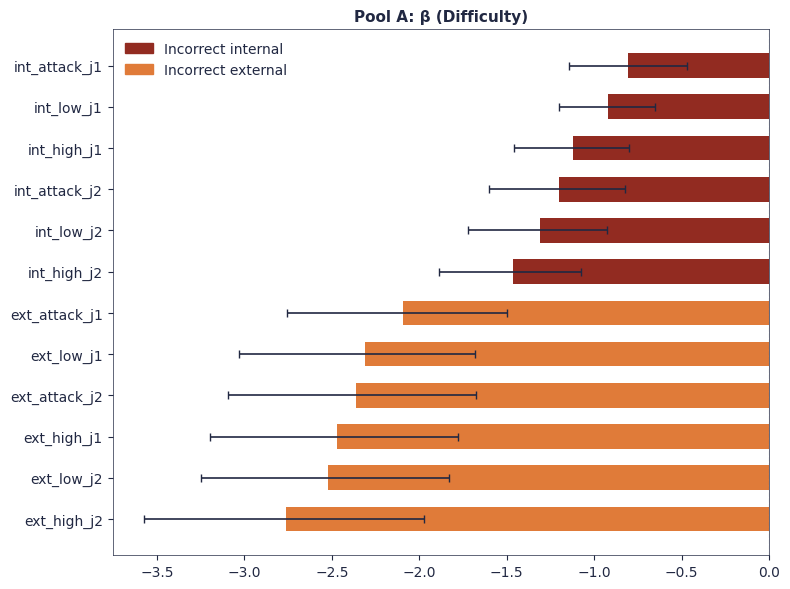

In [49]:
# 2PL-IRT: β (Item difficulty)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def get_color(item):
    return "#922B21" if item.startswith("int") else "#E07B39"

background_color = "#ffff"
item_irt_results = item_irt_results.sort_values("difficulty_mean", ascending=True)
colors = [get_color(i) for i in item_irt_results["item"]]
items = item_irt_results["item"]
y_pos = np.arange(len(items))

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

ax.barh(y_pos, item_irt_results["difficulty_mean"], color=colors, height=0.6)
ax.errorbar(
    item_irt_results["difficulty_mean"], y_pos,
    xerr=[
        item_irt_results["difficulty_mean"] - item_irt_results["difficulty_hdi_3%"],
        item_irt_results["difficulty_hdi_97%"] - item_irt_results["difficulty_mean"]
    ],
    fmt="none", color="#212842", linewidth=1.2, capsize=3
)
ax.set_yticks(y_pos)
ax.set_yticklabels(items, fontsize=10)
ax.set_title("Pool A: β (Difficulty)", fontsize=11, fontweight="bold", color="#212842")
ax.axvline(0, color="#212842", linewidth=0.8, linestyle="--", alpha=0.5)
ax.tick_params(colors="#212842")
for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)

int_patch = mpatches.Patch(color="#922B21", label="Incorrect internal")
ext_patch = mpatches.Patch(color="#E07B39", label="Incorrect external")
ax.legend(handles=[int_patch, ext_patch], loc="upper left",
          fontsize=10, frameon=False, labelcolor="#212842")

plt.tight_layout()
plt.savefig("irt_difficulty.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()


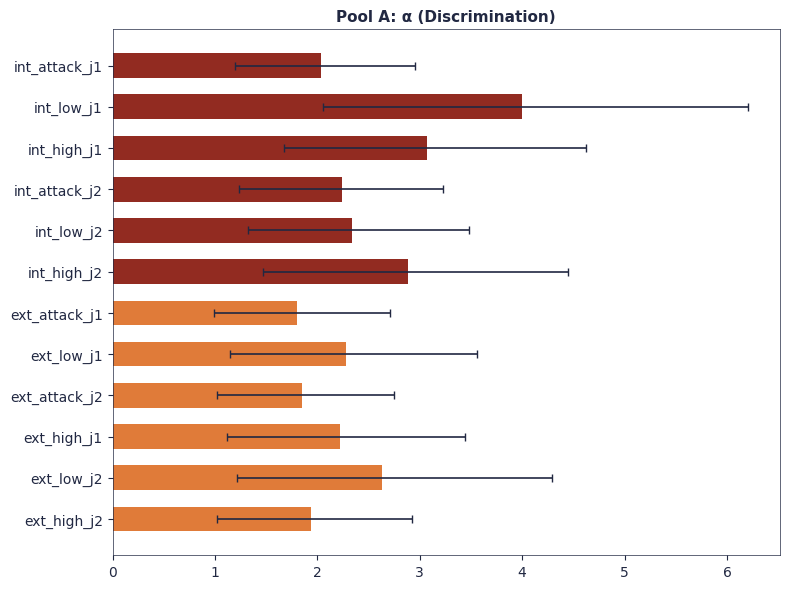

In [52]:
# 2PL-IRT: α (Item discrimination)
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

ax.barh(y_pos, item_irt_results["discrimination_mean"], color=colors, height=0.6)
ax.errorbar(
    item_irt_results["discrimination_mean"], y_pos,
    xerr=[
        item_irt_results["discrimination_mean"] - item_irt_results["discrimination_hdi_3%"],
        item_irt_results["discrimination_hdi_97%"] - item_irt_results["discrimination_mean"]
    ],
    fmt="none", color="#212842", linewidth=1.2, capsize=3
)
ax.set_yticks(y_pos)
ax.set_yticklabels(items, fontsize=10)
ax.set_title("Pool A: α (Discrimination)", fontsize=11, fontweight="bold", color="#212842")
# ax.set_title("α: Item discrimination", fontsize=13, fontweight="bold", color="#212842")
ax.tick_params(colors="#212842")
for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)

# int_patch = mpatches.Patch(color="#922B21", label="Incorrect internal")
# ext_patch = mpatches.Patch(color="#E07B39", label="Incorrect external")
# ax.legend(handles=[int_patch, ext_patch], loc="upper right",
#           fontsize=10, frameon=False, labelcolor="#212842")

plt.tight_layout()
plt.savefig("irt_discrimination.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()


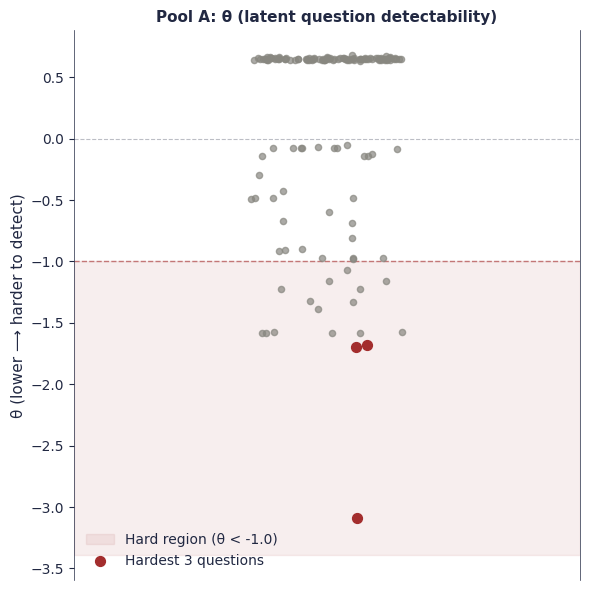

In [51]:
# 2PL-IRT:
background_color = "#ffff"
main_color = "#888780"
outlier_color = "#A32D2D"
threshold = -1.0
n_highlight = 3
jitter_strength = 0.15

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

question_irt_results_sorted = question_irt_results.sort_values("theta_mean", ascending=True).reset_index(drop=True)
y = question_irt_results_sorted["theta_mean"].values

# Jitter x positions
x = np.random.uniform(-jitter_strength, jitter_strength, size=len(y))

# Shaded hard region
ax.axhspan(y.min() - 0.3, threshold, color="#A32D2D", alpha=0.08,
           label=f"Hard region (θ < {threshold})")
ax.axhline(threshold, color="#A32D2D", linewidth=1.0, linestyle="--", alpha=0.6)
ax.axhline(0, color="#212842", linewidth=0.8, linestyle="--", alpha=0.3)

# Main dots
hardest_mask = np.zeros(len(y), dtype=bool)
hardest_mask[:n_highlight] = True

ax.scatter(x[~hardest_mask], y[~hardest_mask],
           color=main_color, s=20, alpha=0.7, zorder=5)
ax.scatter(x[hardest_mask], y[hardest_mask],
           color=outlier_color, s=50, zorder=6,
           label=f"Hardest {n_highlight} questions")

ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("θ (lower ⟶ harder to detect)", fontsize=11, color="#212842")
ax.set_title("Pool A: θ (latent question detectability)", fontsize=11, fontweight="bold", color="#212842")
ax.tick_params(colors="#212842")
ax.legend(fontsize=10, frameon=False, labelcolor="#212842")

for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig("irt_latent_qn.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()
